# Regressione polinomiale

Si ricorre a una regressione polinomiale quando il modello lineare non è soddisfacente. Un segnale tipico di questa necessità è quando si osservano degli andamenti non lineari (es. a parabola) nei grafici dei residui rispetto a una delle variabili predittrici, supponiamo ad esempio la seguente situazione:

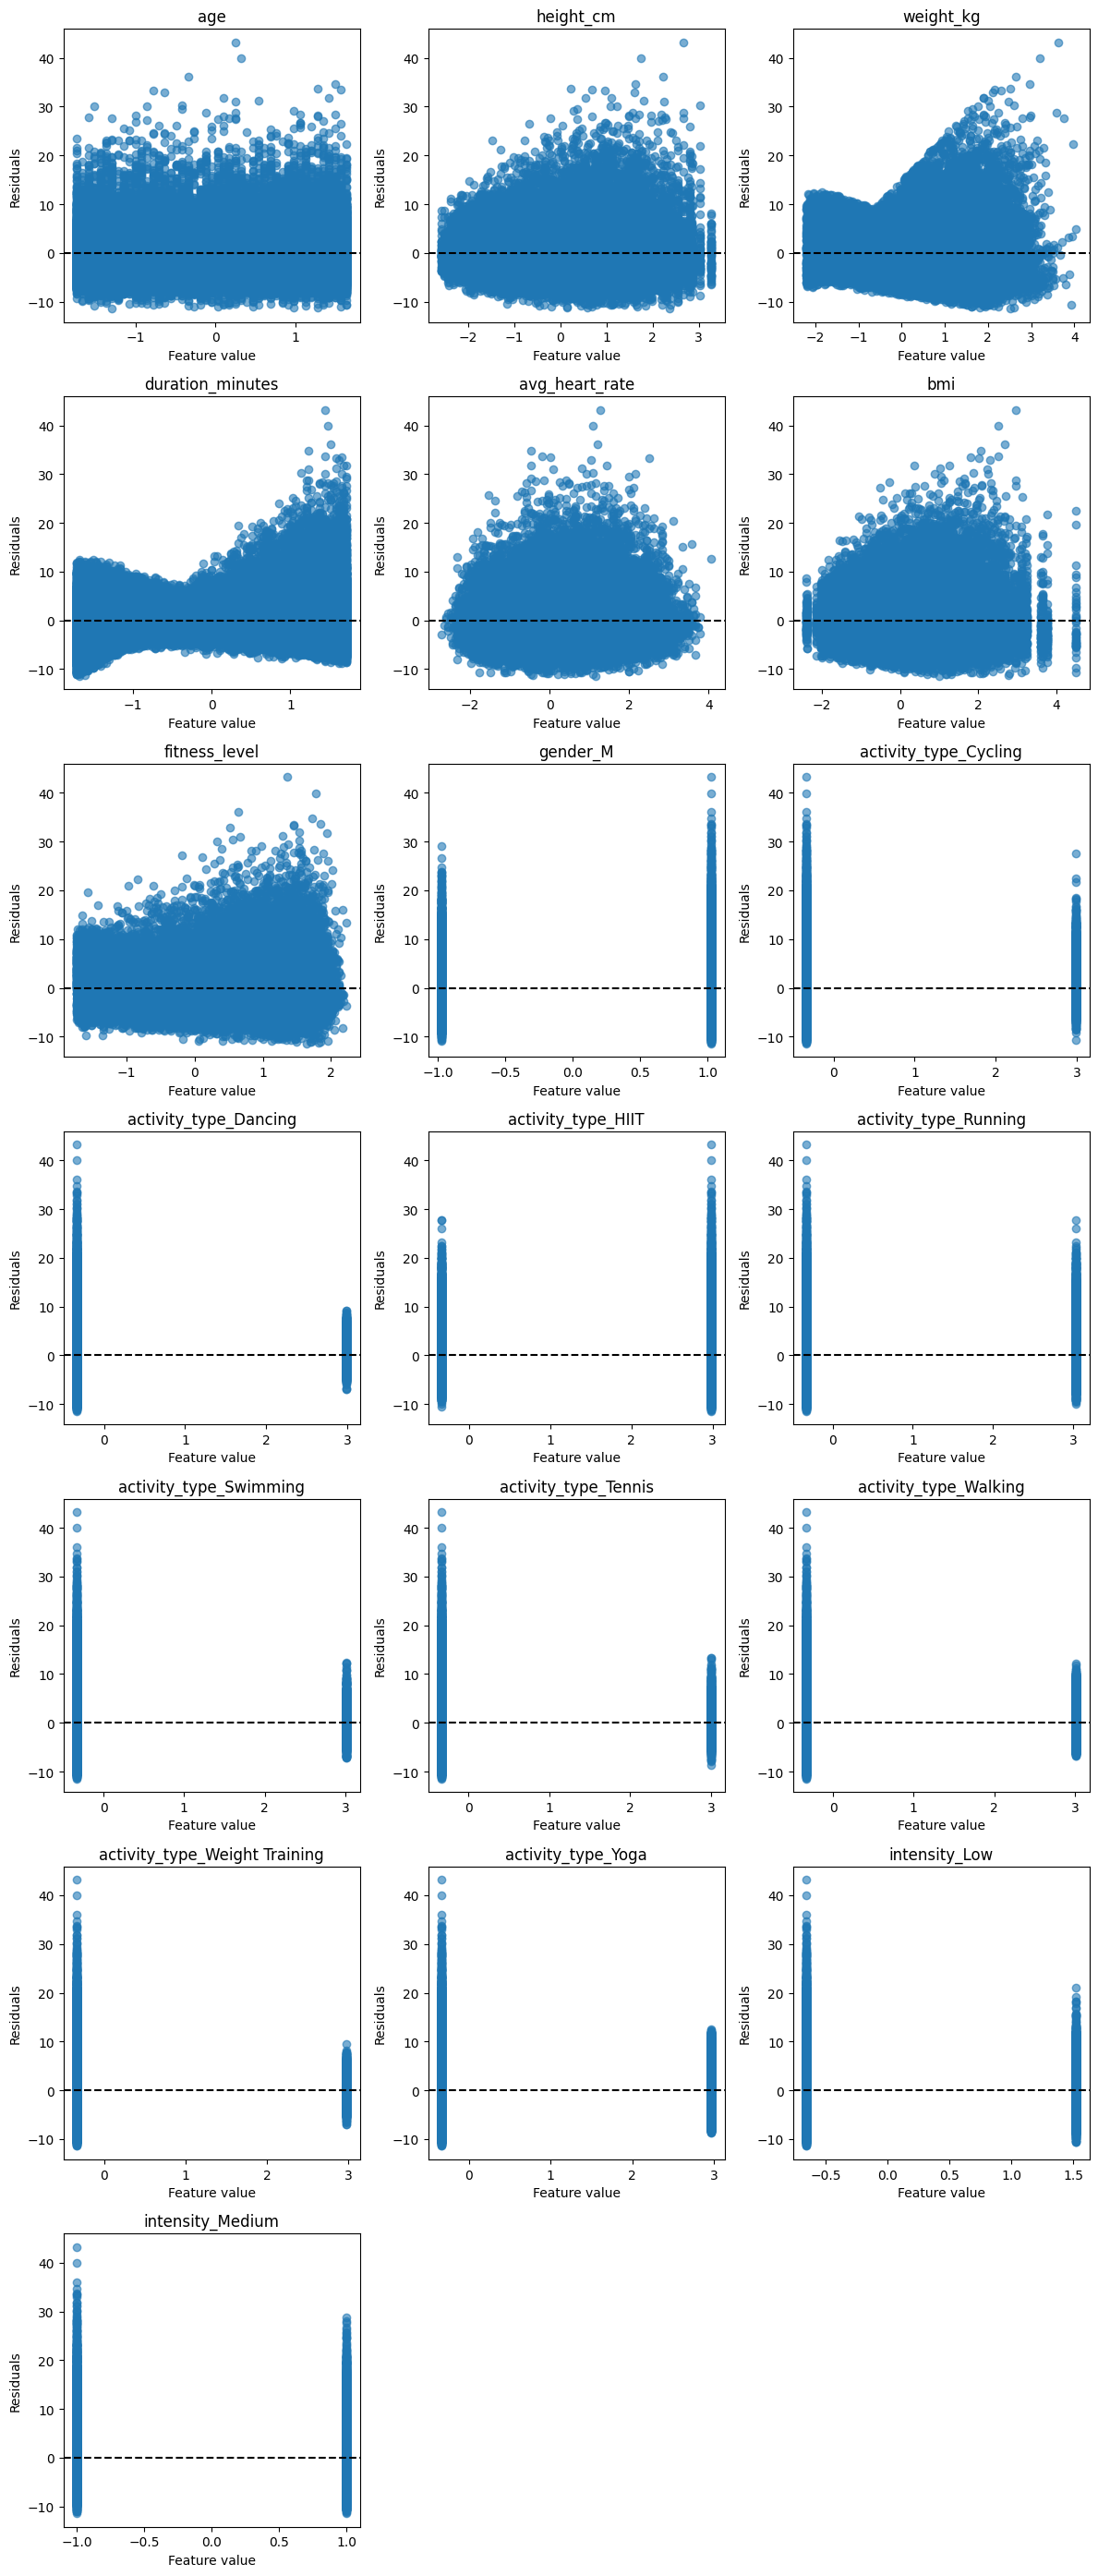

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataframe = pd.read_csv("../db/health_fitness_dataset.csv")

y = dataframe["calories_burned"]
X = dataframe.drop(columns=["calories_burned", "participant_id", "date"])

X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

linear_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
linear_model.fit(X_train, y_train)

linear_y_pred = linear_model.predict(X_test)

residuals = y_test - linear_y_pred

coefs = linear_model.coef_
selected_indices = np.where(coefs != 0)[0]
n_features = len(selected_indices)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()
for i, idx in enumerate(selected_indices):
    feature_name = feature_names[idx]
    axes[i].scatter(X_test[:, idx], residuals, alpha=0.6)
    axes[i].axhline(0, linestyle="--", color="black")
    axes[i].set_title(feature_name)
    axes[i].set_xlabel("Feature value")
    axes[i].set_ylabel("Residuals")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

I grafici che confrontano variabili e residui ci permettono di vedere come cambiano i risultati al cambiare della variabile, i grafici che mostrano un aspetto non lineare risultano essere: 
- weight_kg: i residui tendono ad aumentare all'aumentare del peso.
- height_cm: i residui tendono ad aumentare all'aumentare dell'altezza.
- duration_minutes: i residui tendono ad aumentare all'aumentare della durata.
- avg_heart_rate: i residui sono più alti per valori medi e si abbassano agli estremi.
- bmi: i residui sono più alti per valori medi e si abbassano agli estremi.
- fitness_level: i residui tendono ad aumentare all'aumentare del livello di allenamento.

In questo caso notiamo un andamento non lineare secondo differenti variabili, ciò potrebbe essere risolto andando utilizzare la regressione polinomiale. L'idea alla base consiste nell'aggiungere dei nuovi predittori "fittizzi" (dummy) che sono semplicemente monomi di grado 2 o superiore alle variabili originali, oppure vengono aggiunti dei termini di interazione. Ad esempio partendo da una singola variabile $x$ potremmo costruire:
- Modello lineare: $Y=\beta_0+\beta_1 x + \epsilon$.
- Modello quadratico: $Y=\beta_0+\beta_1 x + \beta_2 x^2 + \epsilon$.
- Modello generale di grado $d$: $Y=\beta_0+\beta_1 x + \beta_2 x^2 + \dots + \beta_d x^d + \epsilon$.
- Modello con termini di interazione: $Y=\beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_1 x_2 + \epsilon$

In tal caso il modello diventerà non lineare nelle variabili, ma comunque rimarrà lineare nei parametri $\beta$. Ciò quindi permetterà comunque di utilizzare il metodo dei minimi quadrati per stimare i parametri.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

def get_selected_indices(X, y):
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X, y)

    coefs = model.coef_
    selected_indices = np.where(coefs != 0)[0]
    return selected_indices

dataframe = pd.read_csv("../db/health_fitness_dataset.csv")

y = dataframe["calories_burned"]
X = dataframe.drop(columns=["calories_burned", "participant_id", "date"])

X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Selezione delle variabili
selected_indices = get_selected_indices(X_train, y_train)
X_train = X_train[:, selected_indices]
X_test = X_test[:, selected_indices]

# Creazione delle variabili sotto forma di polinomi
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

selected_feature_names = feature_names[selected_indices]
poly_feature_names = poly.get_feature_names_out(selected_feature_names)

# Scaling
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# Addestramento
poly_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
poly_model.fit(X_train_poly, y_train)
poly_y_pred = poly_model.predict(X_test_poly)

coefs = poly_model.coef_
selected_features = poly_feature_names[coefs != 0]
print("Variabili selezionate da Elastic Net:")
print(selected_features)

print("\nCoefficienti:")
for name, coef in zip(selected_feature_names, coefs):
    if coef != 0:
        print(f"{name}: {coef}")

Variabili selezionate da Elastic Net:
['height_cm' 'weight_kg' 'duration_minutes' 'avg_heart_rate' 'bmi'
 'fitness_level' 'gender_M' 'activity_type_Dancing' 'activity_type_HIIT'
 'activity_type_Running' 'activity_type_Walking' 'activity_type_Yoga'
 'intensity_Low' 'age duration_minutes' 'height_cm duration_minutes'
 'height_cm bmi' 'height_cm activity_type_HIIT'
 'weight_kg duration_minutes' 'weight_kg avg_heart_rate'
 'weight_kg activity_type_Cycling' 'weight_kg activity_type_Dancing'
 'weight_kg activity_type_HIIT' 'weight_kg activity_type_Running'
 'weight_kg activity_type_Swimming' 'weight_kg activity_type_Walking'
 'weight_kg activity_type_Weight Training' 'weight_kg activity_type_Yoga'
 'weight_kg intensity_Low' 'weight_kg intensity_Medium'
 'duration_minutes avg_heart_rate' 'duration_minutes bmi'
 'duration_minutes fitness_level' 'duration_minutes activity_type_Cycling'
 'duration_minutes activity_type_Dancing'
 'duration_minutes activity_type_HIIT'
 'duration_minutes activity_t

Possiamo testare se effettivamente la regressione polinomiale ha introdotto un qualche miglioramento confrontando i residui dei due modelli.

92.0


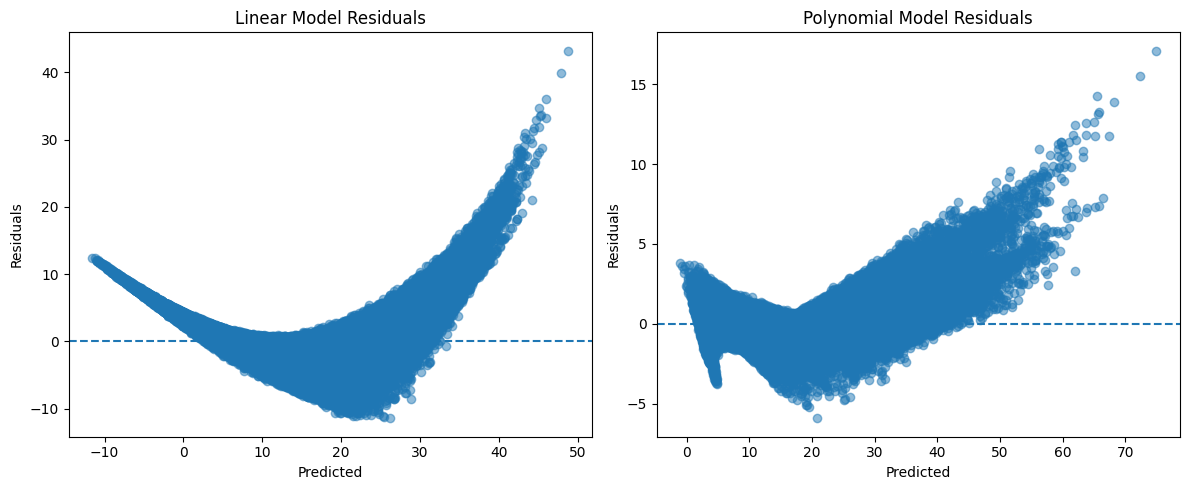

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(linear_y_pred, y_test - linear_y_pred, alpha=0.5)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Linear Model Residuals")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

axes[1].scatter(poly_y_pred, y_test - poly_y_pred, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Polynomial Model Residuals")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

print(max(y_test))
plt.tight_layout()
plt.show()

Dai due grafici possiamo notare come l'introduzione del modello polinomiale ha ridotto in modo significativo l'ampiezza dei residui, tuttavia possiamo notare come la varianza non sia costante (**eteroschedasticità**). Questa ultima affermazione va in contrasto con l'assunzione per cui la regressione lineare debba avere varianza costante. La violazione di questa assunzione è dovuta a errori standard che diventano distorti.

## Polinomi sulle varabili dummy

Notare che l'utilizzo dei polinomi sulle variabili dummy (0/1) risulta completamente inutile, di fatti in questo caso avremo che:

$$
x^2 = x
$$

allo stesso modo anche l'interazione tra le variabili dummy di una categoria risulterà inutile questo perché:

$$
x_{cat_i} * x_{cat_j}
$$

risulterà sempre 0.